In [193]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [194]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import utils

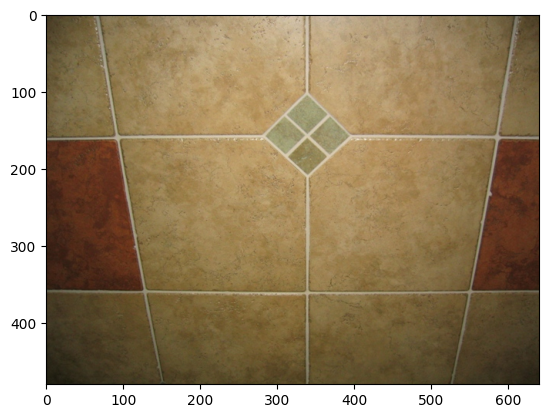

In [195]:
feature: str = "tiles5"
file_path: str = f"data/q1/{feature}.jpg"

img: np.ndarray = cv.imread(file_path, cv.IMREAD_COLOR_RGB)
plt.imshow(img)
plt.show()

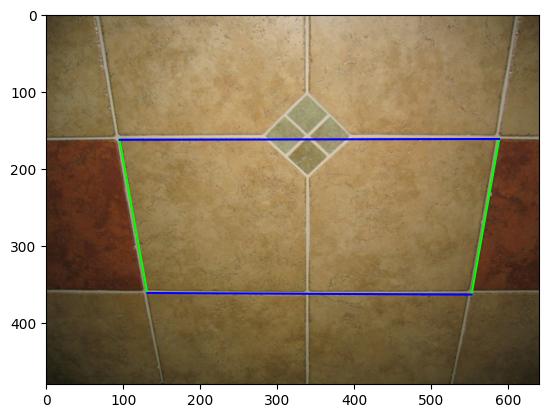

In [196]:
# Read the annotations.
points = utils.read_annotations("data/annotation/q1_annotation.npy", feature)

# Draw annotated image.
plt.imshow(img)
plt.plot(points[0:2, 0], points[0:2, 1], c="#0F0")
plt.plot(points[2:4, 0], points[2:4, 1], c="#0F0")
plt.plot(points[4:6, 0], points[4:6, 1], c="#00F")
plt.plot(points[6:8, 0], points[6:8, 1], c="#00F")
plt.show()

In [197]:
# Constructing the homography.
h: np.ndarray = utils.affine_rectification(points)
h

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 2.92179095e-05, -6.58301828e-04,  1.00000000e+00]])

In [200]:
# Testing parallelism.
h_inv: np.ndarray = np.linalg.inv(h)

cosines: list[float] = []
for i in range(0, len(points), 4):
    l1: np.ndarray = utils.cross(points[i], points[i + 1])
    l2: np.ndarray = utils.cross(points[i + 2], points[i + 3])
    l1_prime: np.ndarray = l1.T @ h_inv
    l2_prime: np.ndarray = l2.T @ h_inv
    cosines.append((utils.cosine(l1, l2), utils.cosine(l1_prime, l2_prime)))

# Pretty printing.
np.array(cosines)

array([[0.93752996, 1.        ],
       [0.99997702, 1.        ],
       [0.98683276, 0.9999252 ],
       [0.99871911, 0.99993835]])

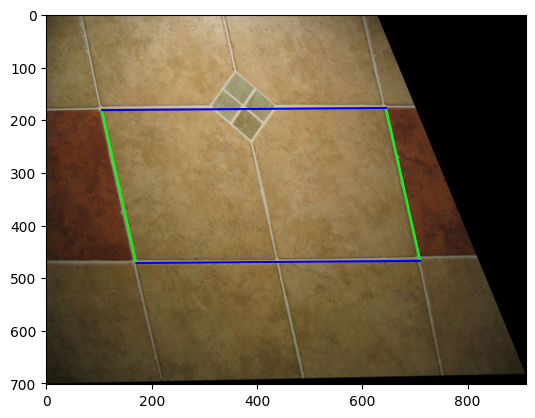

In [199]:
# Draw affine-rectified image with rectified annotations.
aff_image: np.ndarray = utils.warp(img, h)
aff_points: np.ndarray = utils.normalize(points @ h.T)

# Draw annotated image.
plt.imshow(aff_image)
plt.plot(aff_points[0:2, 0], aff_points[0:2, 1], c="#0F0")
plt.plot(aff_points[2:4, 0], aff_points[2:4, 1], c="#0F0")
plt.plot(aff_points[4:6, 0], aff_points[4:6, 1], c="#00F")
plt.plot(aff_points[6:8, 0], aff_points[6:8, 1], c="#00F")
plt.show()